<a href="https://colab.research.google.com/github/dnanaat/PCVK_Genap_2026/blob/main/Week5_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<BarContainer object of 256 artists>

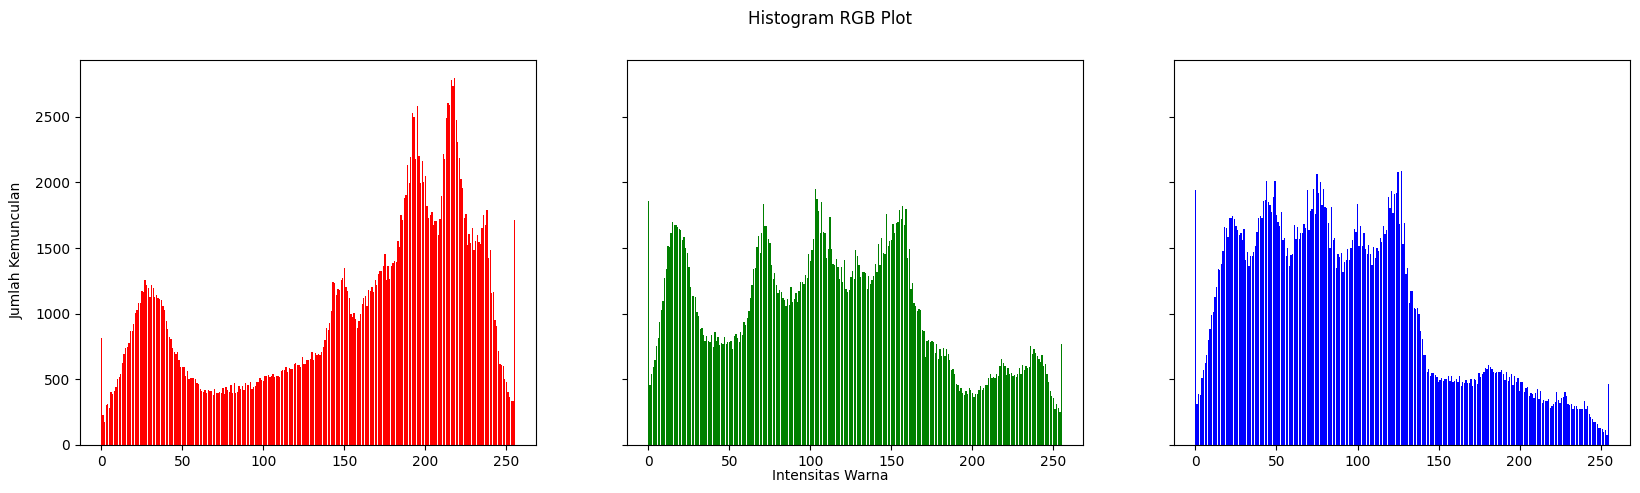

In [3]:
#PRAKTIKUM 1

import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

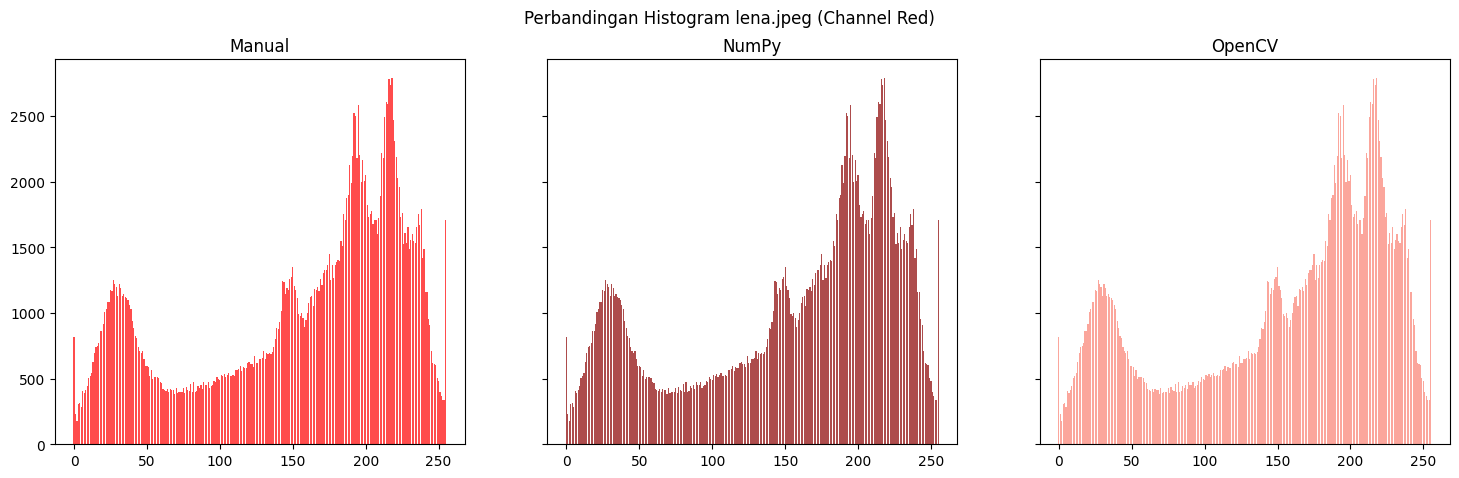

Selisih maksimal Manual vs NumPy: 0
Selisih maksimal Manual vs OpenCV: 0.0
Selisih maksimal NumPy vs OpenCV: 0.0


Selisih maksimal pada KTM1b.jpg (Red Channel): 0


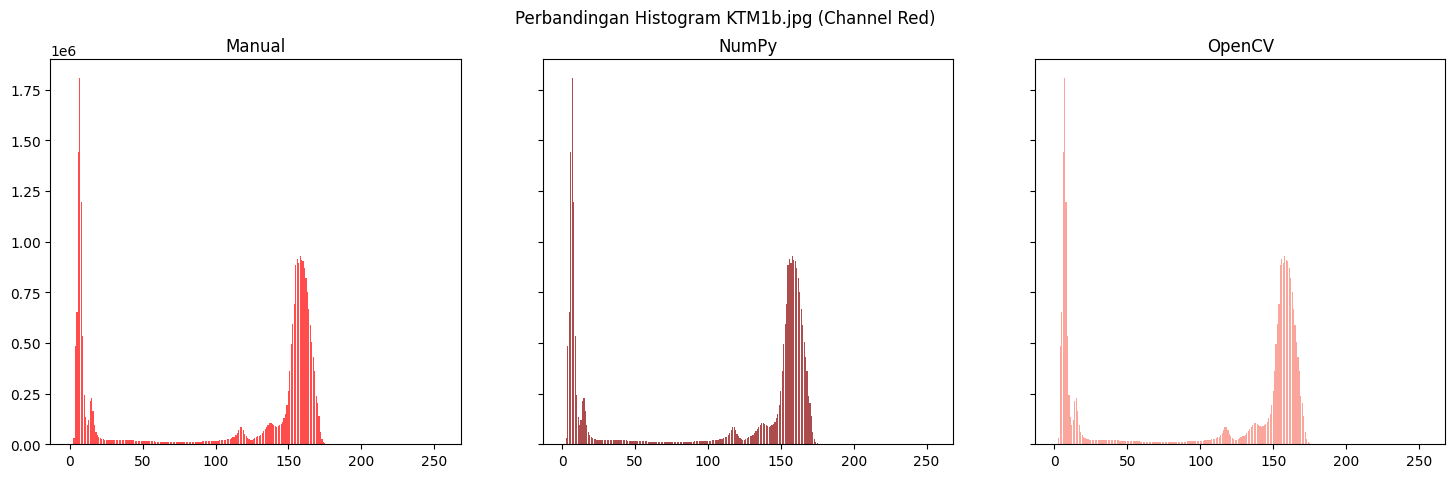

In [14]:
#PERTANYAAN PRAKTIKUM 1

#BAGIAN 1 - LENA

# 1. Menggunakan NumPy
hist_np_red, _ = np.histogram(img[:,:,0], bins=256, range=(0,256))
hist_np_green, _ = np.histogram(img[:,:,1], bins=256, range=(0,256))
hist_np_blue, _ = np.histogram(img[:,:,2], bins=256, range=(0,256))

# 2. Menggunakan cv.calcHist
hist_cv_red = cv.calcHist([img], [0], None, [256], [0,256]).flatten()
hist_cv_green = cv.calcHist([img], [1], None, [256], [0,256]).flatten()
hist_cv_blue = cv.calcHist([img], [2], None, [256], [0,256]).flatten()

# Menampilkan perbandingan grafik histogram untuk Channel Merah (Red)
fig1, axs1 = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
fig1.suptitle('Perbandingan Histogram lena.jpeg (Channel Red)')

# Plot Manual
axs1[0].bar(np.arange(256), red, color='red', alpha=0.7)
axs1[0].set_title('Manual')

# Plot NumPy
axs1[1].bar(np.arange(256), hist_np_red, color='darkred', alpha=0.7)
axs1[1].set_title('NumPy')

# Plot OpenCV
axs1[2].bar(np.arange(256), hist_cv_red.flatten(), color='salmon', alpha=0.7)
axs1[2].set_title('OpenCV')

plt.show()

# 3. Menghitung Selisih Maksimum (Manual vs Numpy vs OpenCV)
diff_np_manual = max(np.max(np.abs(red - hist_np_red)),
                     np.max(np.abs(green - hist_np_green)),
                     np.max(np.abs(blue - hist_np_blue)))

diff_cv_manual = max(np.max(np.abs(red - hist_cv_red)),
                     np.max(np.abs(green - hist_cv_green)),
                     np.max(np.abs(blue - hist_cv_blue)))

diff_np_cv = max(np.max(np.abs(hist_np_red - hist_cv_red)),
                 np.max(np.abs(hist_np_green - hist_cv_green)),
                 np.max(np.abs(hist_np_blue - hist_cv_blue)))

print(f"Selisih maksimal Manual vs NumPy: {diff_np_manual}")
print(f"Selisih maksimal Manual vs OpenCV: {diff_cv_manual}")
print(f"Selisih maksimal NumPy vs OpenCV: {diff_np_cv}")

#-----------------------------------------------------------
print('\n')
#BAGIAN 2 - KTM Daana

path_ktm1b = '/content/drive/MyDrive/PCVK/KTM_Daana.jpg'
if os.path.exists(path_ktm1b):
    img_ktm = cv.imread(path_ktm1b)
    img_ktm = cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB)

    # Hitung NumPy & OpenCV
    h_np, _ = np.histogram(img_ktm[:,:,0], bins=256, range=(0,256))
    h_cv = cv.calcHist([img_ktm], [0], None, [256], [0,256]).flatten()

    # Hitung Manual (Channel Red saja sebagai pembuktian efisien)
    h_manual = [0]*256
    h_ktm, w_ktm, _ = img_ktm.shape
    for y in range(h_ktm):
        for x in range(w_ktm):
            h_manual[img_ktm[y][x][0]] += 1

    diff_ktm = max(np.max(np.abs(h_manual - h_np)), np.max(np.abs(h_manual - h_cv)))
    print(f"Selisih maksimal pada KTM1b.jpg (Red Channel): {diff_ktm}")
else:
    print(f"File {path_ktm1b} tidak ditemukan untuk diuji.")

if os.path.exists(path_ktm1b):
    fig1b, axs1b = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
    fig1b.suptitle('Perbandingan Histogram KTM1b.jpg (Channel Red)')

    # Plot Manual
    axs1b[0].bar(np.arange(256), h_manual, color='red', alpha=0.7)
    axs1b[0].set_title('Manual')

    # Plot NumPy
    axs1b[1].bar(np.arange(256), h_np, color='darkred', alpha=0.7)
    axs1b[1].set_title('NumPy')

    # Plot OpenCV
    axs1b[2].bar(np.arange(256), h_cv, color='salmon', alpha=0.7)
    axs1b[2].set_title('OpenCV')

    plt.show()
else:
    print(f"File {path_ktm1b} tidak ditemukan, grafik tidak dapat ditampilkan.")

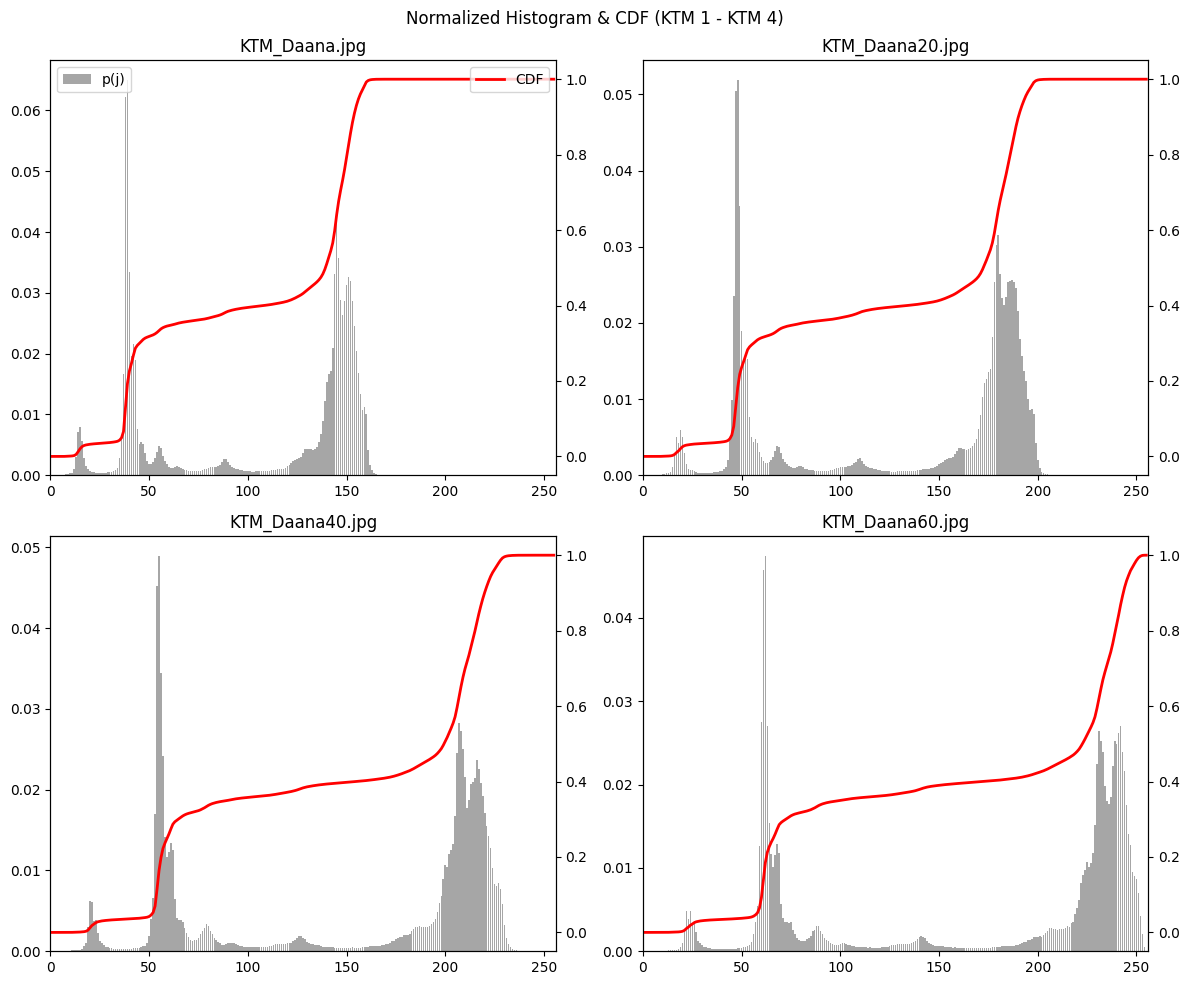

In [15]:
#PERTANYAAN 2

ktm_files = ['KTM_Daana.jpg', 'KTM_Daana20.jpg', 'KTM_Daana40.jpg', 'KTM_Daana60.jpg']
fig2, axs2 = plt.subplots(2, 2, figsize=(12, 10))
fig2.suptitle('Normalized Histogram & CDF (KTM 1 - KTM 4)')

axs2 = axs2.ravel() # Flatten array axis untuk iterasi mudah

for i, filename in enumerate(ktm_files):
    filepath = f'/content/drive/MyDrive/PCVK/{filename}'
    if os.path.exists(filepath):
        # Gunakan grayscale agar analisis brightness/CDF lebih jelas
        img_gray = cv.imread(filepath, cv.IMREAD_GRAYSCALE)

        # Hitung histogram dan normalisasi p(j)
        hist, bins = np.histogram(img_gray.flatten(), 256, [0,256])
        p_j = hist / hist.sum() # Histogram ternormalisasi

        # Hitung CDF
        cdf = p_j.cumsum()

        # Plot Histogram
        axs2[i].bar(np.arange(256), p_j, color='gray', alpha=0.7, label='p(j)')

        # Plot CDF (Gunakan sumbu y kedua (twinx) agar skala terlihat)
        ax2_twin = axs2[i].twinx()
        ax2_twin.plot(cdf, color='red', linewidth=2, label='CDF')

        axs2[i].set_title(filename)
        axs2[i].set_xlim([0,256])
        if i == 0:
            axs2[i].legend(loc='upper left')
            ax2_twin.legend(loc='upper right')
    else:
        axs2[i].text(0.5, 0.5, f"{filename} not found", ha='center')

plt.tight_layout()
plt.show()

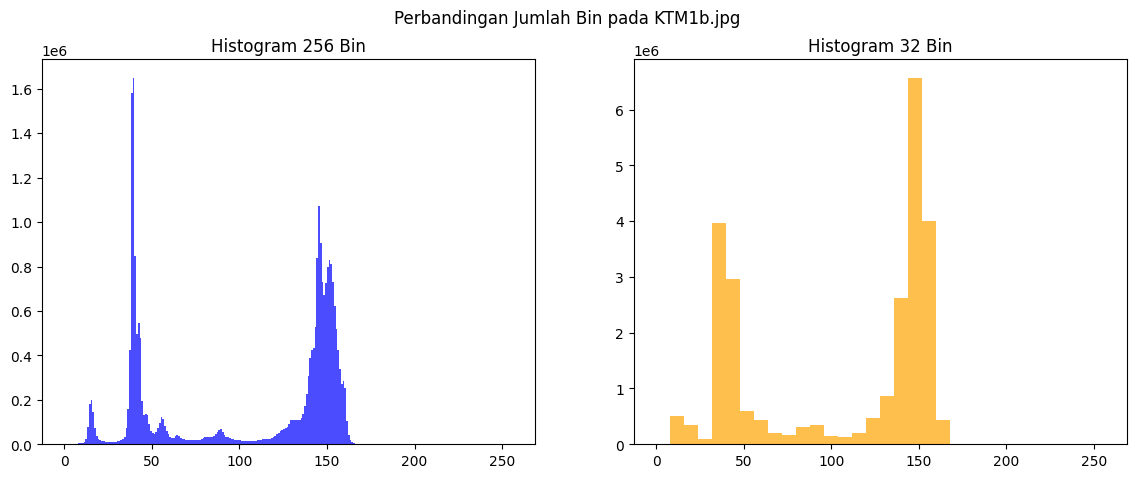

In [16]:
#PERTANYAAN 3

PARAM = {'bins': 32} # Contoh jumlah bin yang dikurangi (misal 32)

if os.path.exists(path_ktm1b):
    img_ktm1b_gray = cv.imread(path_ktm1b, cv.IMREAD_GRAYSCALE)

    fig3, axs3 = plt.subplots(1, 2, figsize=(14, 5))
    fig3.suptitle("Perbandingan Jumlah Bin pada KTM1b.jpg")

    # Histogram 256 Bin
    axs3[0].hist(img_ktm1b_gray.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
    axs3[0].set_title("Histogram 256 Bin")

    # Histogram PARAM['bins']
    axs3[1].hist(img_ktm1b_gray.ravel(), bins=PARAM['bins'], range=(0, 256), color='orange', alpha=0.7)
    axs3[1].set_title(f"Histogram {PARAM['bins']} Bin")

    plt.show()

Selisih maksimum Manual vs OpenCV pada lena.jpeg: 1


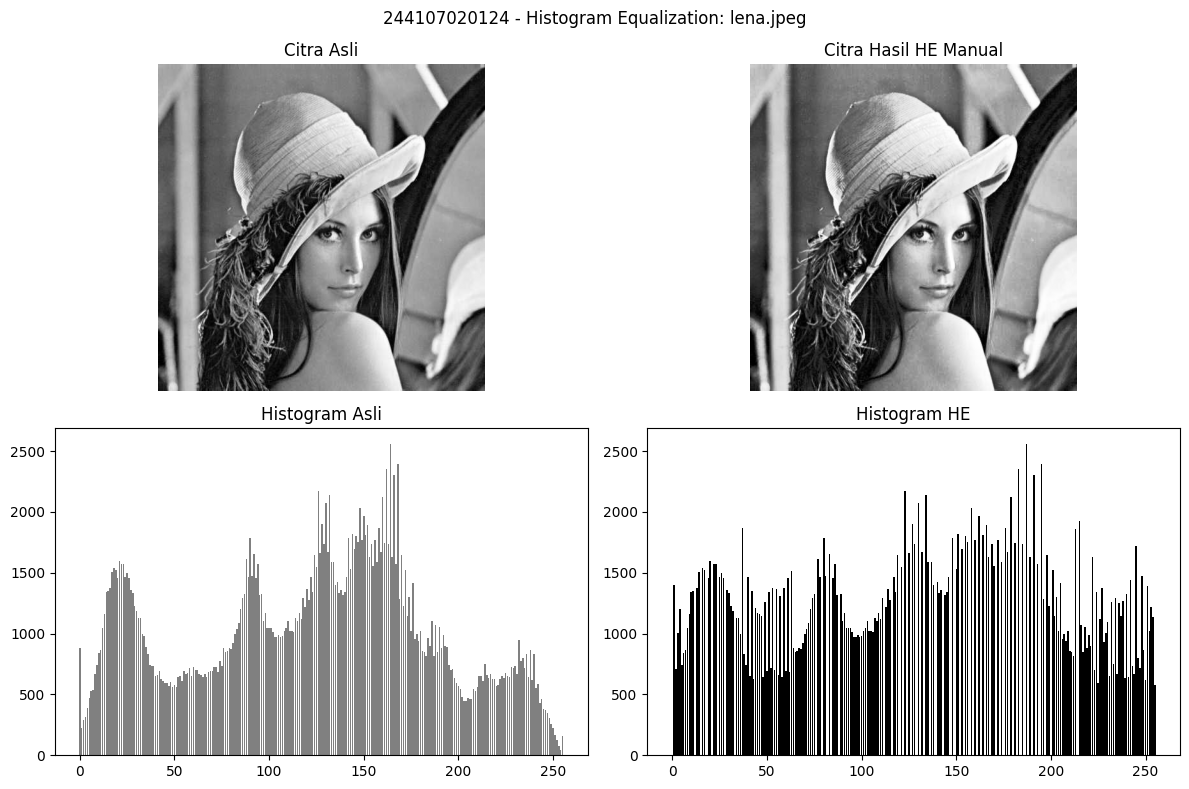

Selisih maksimum Manual vs OpenCV pada KTM_Daana.jpg: 0


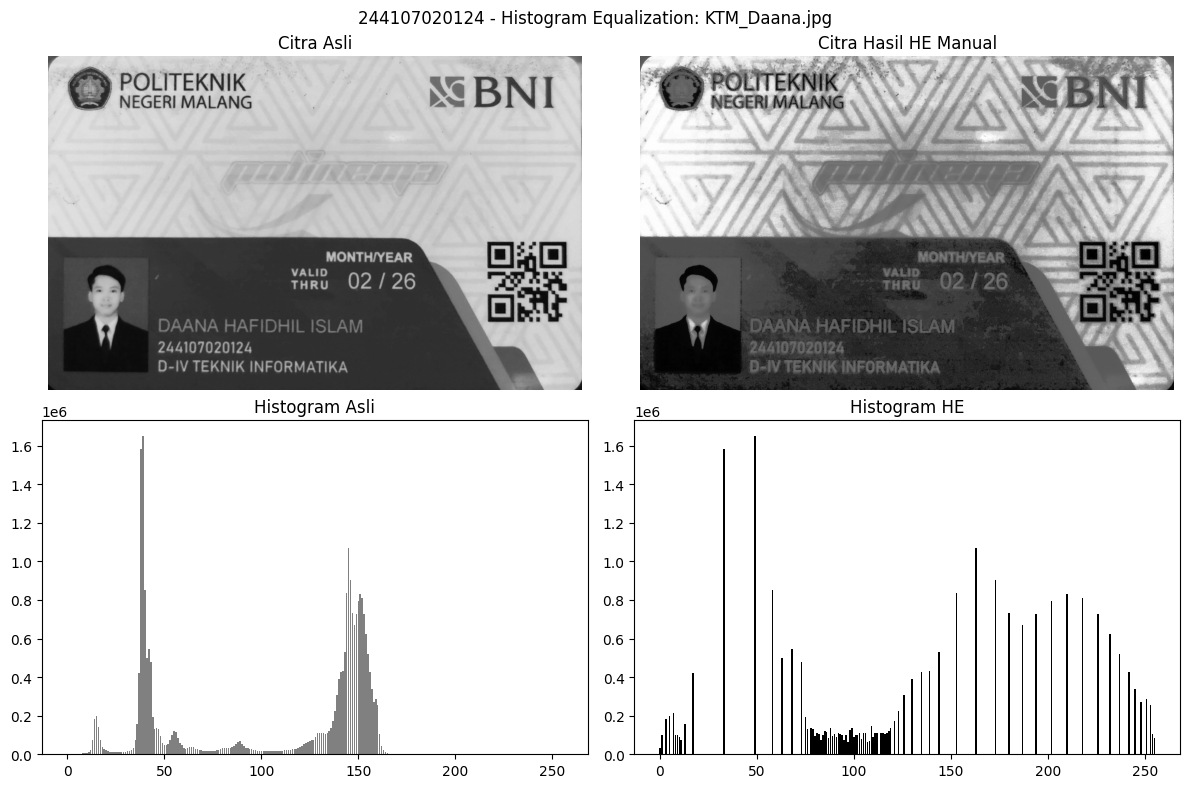

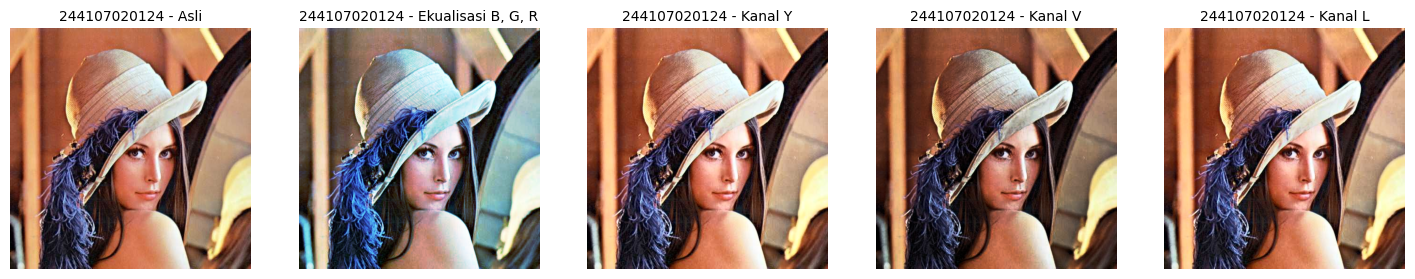


--- Pengukuran Kecerahan & Hue pada lena.jpeg ---
Cara                    geser Hue (der)    rerata terang
Asli                               0.00            122.2
Ekualisasi B, G, R                53.03            127.4
Kanal Y                            0.40            127.9
Kanal V                            0.87            100.6
Kanal L                            1.65            122.7


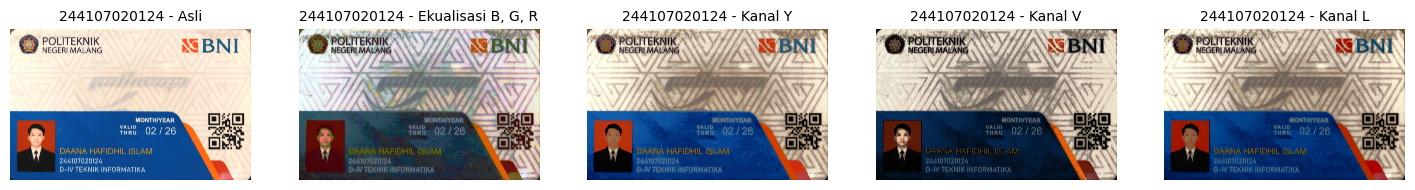


--- Pengukuran Kecerahan & Hue pada KTM_Daana60.jpg ---
Cara                    geser Hue (der)    rerata terang
Asli                               0.00            168.1
Ekualisasi B, G, R                66.56            130.7
Kanal Y                            1.19            130.5
Kanal V                            0.89            115.8
Kanal L                            3.50            122.4


In [24]:
NIM = '244107020124'

# Fungsi Histogram Equalization Manual berdasarkan Flowchart
def he_manual(img_gray):
    # 1. Menghitung jumlah kemunculan (Frekuensi)
    hist, _ = np.histogram(img_gray.flatten(), 256, [0,256])

    # 2. Penjumlahan kumulatif dari frekuensi
    cdf = hist.cumsum()

    # 3. Normalisasi & Skala (dibagi jumlah pixel lalu dikali 255)
    total_pixels = img_gray.shape[0] * img_gray.shape[1]
    cdf_normalized = np.round((cdf / total_pixels) * 255).astype(np.uint8)

    # 4. Transformasi kembali dalam bentuk citra
    img_eq = cdf_normalized[img_gray]

    return img_eq, hist, cdf_normalized

def uji_he(img_path, title):
    if not os.path.exists(img_path):
        print(f"[-] File {img_path} tidak ditemukan.")
        return

    # Baca grayscale
    img_gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

    # Eksekusi HE Manual
    img_eq_manual, hist_asli, _ = he_manual(img_gray)
    hist_eq_manual, _ = np.histogram(img_eq_manual.flatten(), 256, [0,256])

    # Eksekusi HE OpenCV
    img_eq_cv = cv.equalizeHist(img_gray)

    # Hitung selisih maksimum Manual vs OpenCV
    diff = np.max(np.abs(img_eq_manual.astype(np.int16) - img_eq_cv.astype(np.int16)))
    print(f"Selisih maksimum Manual vs OpenCV pada {title}: {diff}")

    # Tampilkan Citra Asli, Citra HE Manual, dan Histogram (Sesuai Langkah 1)
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{NIM} - Histogram Equalization: {title}')

    axs[0,0].imshow(img_gray, cmap='gray'); axs[0,0].set_title('Citra Asli'); axs[0,0].axis('off')
    axs[0,1].imshow(img_eq_manual, cmap='gray'); axs[0,1].set_title('Citra Hasil HE Manual'); axs[0,1].axis('off')

    axs[1,0].bar(range(256), hist_asli, color='gray'); axs[1,0].set_title('Histogram Asli')
    axs[1,1].bar(range(256), hist_eq_manual, color='black'); axs[1,1].set_title('Histogram HE')

    plt.tight_layout()
    plt.show()

# Tahap 1: lena.jpeg (Citra Contoh)
uji_he('/content/drive/MyDrive/PCVK/lena.jpeg', 'lena.jpeg')
# Tahap 2: KTM1a.jpg (Citra Sendiri - Ruangan Gelap)
uji_he('/content/drive/MyDrive/PCVK/KTM_Daana.jpg', 'KTM_Daana.jpg')


def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d) # Hue melingkar 0-179
    return d.mean()

def uji_he_warna(img_path, title):
    if not os.path.exists(img_path): return
    bgr = cv.imread(img_path)

    # Cara 1: Tiap kanal B, G, R diekualisasi sendiri
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # Cara 2: Kanal Terang Saja (YCrCb, HSV, LAB)
    # YCrCb
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # HSV
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h_chan, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h_chan, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    # LAB
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b_chan = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b_chan]), cv.COLOR_LAB2BGR)

    # Tampilkan Gambar
    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(f"{NIM} - {t}", fontsize=10)
        plt.axis('off')
    plt.show()

    # Print Tabel
    print(f"\n--- Pengukuran Kecerahan & Hue pada {title} ---")
    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    for t, c in zip(judul, citra):
        print('%-22s %16.2f %16.1f' % (
            t,
            geser_hue(bgr, c) * 2,
            cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
        ))

# Tahap 1: lena.jpeg
uji_he_warna('/content/drive/MyDrive/PCVK/lena.jpeg', 'lena.jpeg')
# Tahap 2: KTM
uji_he_warna('/content/drive/MyDrive/PCVK/KTM_Daana60.jpg', 'KTM_Daana60.jpg')

1c. Nilai PSNR antara KTM Asli dan Global HE: 15.87 dB

2a. Menerapkan CLAHE dengan clipLimit = 3.0


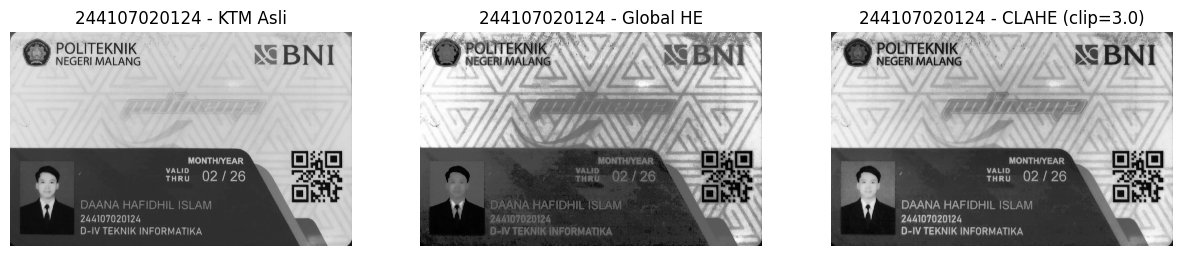

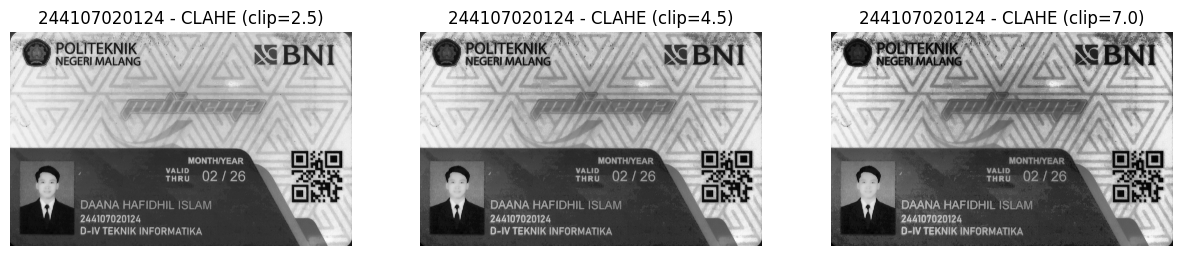

In [26]:
#PERTANYAAN PRAKTIKUM 2

NIM = '244107020124'
N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1)
}

def hitung_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0: return float('inf')
    return 10 * math.log10((255.0 ** 2) / mse)

# Menggunakan path langsung sesuai kode Anda sebelumnya
path_ktm1a = '/content/drive/MyDrive/PCVK/KTM_Daana.jpg'

if os.path.exists(path_ktm1a):
    img_ktm1a = cv.imread(path_ktm1a, cv.IMREAD_GRAYSCALE)
    img_ktm1a_he = cv.equalizeHist(img_ktm1a)

    # Jawaban E2-1: Hitung PSNR
    psnr_val = hitung_psnr(img_ktm1a, img_ktm1a_he)
    print(f"1c. Nilai PSNR antara KTM Asli dan Global HE: {psnr_val:.2f} dB")

    # Jawaban E2-2: CLAHE vs Global HE
    clahe_default = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
    img_clahe = clahe_default.apply(img_ktm1a)

    print(f"\n2a. Menerapkan CLAHE dengan clipLimit = {PARAM['clip']}")
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img_ktm1a, cmap='gray'); axs[0].set_title(f"{NIM} - KTM Asli"); axs[0].axis('off')
    axs[1].imshow(img_ktm1a_he, cmap='gray'); axs[1].set_title(f"{NIM} - Global HE"); axs[1].axis('off')
    axs[2].imshow(img_clahe, cmap='gray'); axs[2].set_title(f"{NIM} - CLAHE (clip={PARAM['clip']})"); axs[2].axis('off')
    plt.show()

    # 2b. Mencoba 3 nilai clipLimit lain di sekitar PARAM['clip']
    test_clips = [PARAM['clip'] - 0.5, PARAM['clip'] + 1.5, PARAM['clip'] + 4.0]
    # Memastikan tidak ada clip limit <= 0
    test_clips = [c if c > 0 else 0.5 for c in test_clips]

    fig2, axs2 = plt.subplots(1, 3, figsize=(15, 5))
    for i, clip in enumerate(test_clips):
        clahe_test = cv.createCLAHE(clipLimit=clip, tileGridSize=(PARAM['tile'], PARAM['tile']))
        img_clahe_test = clahe_test.apply(img_ktm1a)
        axs2[i].imshow(img_clahe_test, cmap='gray')
        axs2[i].set_title(f"{NIM} - CLAHE (clip={clip:.1f})")
        axs2[i].axis('off')
    plt.show()
else:
    print(f"[-] File {path_ktm1a} tidak ditemukan. Pastikan ejaan dan lokasinya benar.")